In [1]:
import copy
import os
import joblib
import sys
import types
import pickle

from cairosvg.svg import svg
from mlxtend.evaluate import feature_importance

root_dir = '../../../before_results/cof_rth_0.99/'
best_models = [
    'random_forest/features_rth_0.99_ecfp_2_1024_True_estate_sum_descriptor_False',
]

with open(os.path.join(root_dir, best_models[0], 'feature_importance.pickle'), 'rb') as f:
    feature_importance_1 = joblib.load(f)

In [2]:
feature_importance_1

[('tree',
  array([[  0.        ,   0.        ,   0.        , ...,  -1.51837516,
           -3.19782359,  24.35562211],
         [  0.        ,   0.        ,   0.        , ...,  -1.51837516,
           23.71717885,  -9.16328577],
         [  0.        ,   0.        ,   0.        , ...,   4.25955418,
           14.37206604,  -4.51388403],
         ...,
         [  0.        ,   0.        ,   0.        , ...,   0.67603076,
          -10.76606678,  -7.35446583],
         [  0.        ,   0.        ,   0.        , ...,  -1.95918905,
           16.56588343,  -9.16328577],
         [  0.        ,   0.        ,   0.        , ...,  -1.89948444,
           23.74054088,  -9.16328577]], shape=(12, 419))),
 ('tree',
  array([[ -0.04624365,   0.        ,   0.        , ...,   3.34932113,
           18.76271016,  11.20329749],
         [  0.35790238,   0.        ,   0.        , ...,   1.67780884,
           18.88023557,  11.43875005],
         [ -0.02196043,   0.        ,   0.        , ...,  -2.29463

In [3]:
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
import pandas as pd

def custom_discretization(y: pd.DataFrame, num_bins: int = 4) -> pd.DataFrame:
    """
    Discretization of the continuous target attribute.
    :param y: dataframe with target
    :param num_bins: number of capacity bins to use
    :return: discretized target attribute
    """
    binned_capacity = pd.qcut(y[y.columns[0]], q=num_bins, labels=False)
    return binned_capacity

def custom_data_kfold(X: pd.DataFrame, y: pd.DataFrame, num_splits: int, num_bins: int = 4, random_state: int = 42) -> list:
    """
    Performs custom data split on the provided data
    :param X: dataframe with molecules and generated features
    :param y: dataframe with target
    :param num_splits: number of folds
    :param num_bins: number of capacity bins to use
    :param random_state: random state (default: 42)
    :return: generated splits (indices)
    """
    binned_capacity = custom_discretization(y, num_bins)
    if len(y) < 50:
        print('aaa')
        splits = 3
        repetitions = int(np.ceil(num_splits / splits))
        skf = RepeatedStratifiedKFold(n_splits=splits, n_repeats=repetitions, random_state=random_state)
    else:
        skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=random_state)
    kfolds = list(skf.split(X, binned_capacity))
    return kfolds

dataset = pd.read_csv('../../../data/before_predictor/cof/rth_0.99/features/features_rth_0.99_ecfp_2_1024_True_estate_sum_descriptor_False.csv')
X = dataset.drop(columns=["capacity_max", "smiles"])
y = dataset[["capacity_max"]]
folds = custom_data_kfold(X, y, num_splits=10, num_bins=10, random_state=42)
test_sets = [f for _, f in folds]
smiles_lists = [dataset['smiles'].iloc[ts] for ts in test_sets]
target_lists = [y.iloc[ts] for ts in test_sets]
smiles_lists = pd.concat(smiles_lists)
target_lists = pd.concat(target_lists)
smiles_lists = smiles_lists.reset_index(drop=True)
target_lists = target_lists.reset_index(drop=True)
smiles_lists = smiles_lists.tolist()
target_lists = target_lists.values.flatten().tolist()
test_sets = [X.iloc[ts, :] for ts in test_sets]
test_sets

[     ecfp_1  ecfp_4  ecfp_8  ecfp_14  ecfp_15  ecfp_17  ecfp_18  ecfp_20  \
 1       2.0     2.0     0.0      0.0      0.0      0.0      0.0      0.0   
 8       0.0     2.0     0.0      0.0      0.0      0.0      0.0      0.0   
 11      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 38      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 43      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 49      0.0     0.0     0.0      4.0      0.0      0.0      0.0      0.0   
 52      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 53      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 62      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 73      0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 106     0.0     0.0     0.0      0.0      0.0      0.0      0.0      0.0   
 107     0.0     0.0     0.0      0.0      2.0      0.0      0.0      0.0   

In [4]:
target_lists

[255.0,
 291.0,
 66.0,
 68.0,
 291.0,
 404.0,
 16.0,
 577.0,
 550.0,
 141.0,
 218.0,
 153.0,
 228.0,
 468.0,
 379.0,
 88.0,
 31.0,
 150.0,
 277.0,
 383.0,
 18.0,
 362.0,
 694.0,
 48.0,
 383.0,
 256.0,
 231.0,
 51.0,
 14.0,
 587.0,
 84.0,
 183.0,
 354.0,
 576.0,
 3.0,
 244.0,
 335.0,
 67.0,
 2.0,
 380.0,
 444.0,
 185.0,
 231.0,
 181.0,
 237.0,
 703.0,
 228.0,
 33.0,
 423.0,
 388.0,
 407.0,
 166.0,
 14.0,
 52.0,
 122.0,
 208.0,
 284.0,
 227.0,
 251.0,
 640.0,
 404.0,
 280.0,
 663.0,
 224.0,
 17.0,
 75.0,
 430.0,
 322.0,
 165.0,
 393.0,
 40.0,
 435.0,
 310.0,
 400.0,
 231.0,
 6.0,
 585.0,
 51.0,
 98.0,
 768.0,
 143.0,
 273.0,
 269.0,
 379.0,
 500.0,
 589.0,
 49.0,
 73.0,
 209.0,
 5.0,
 163.0,
 583.0,
 382.0,
 298.0,
 393.0,
 256.0,
 724.0,
 15.0,
 209.0,
 83.0,
 55.0,
 208.0,
 425.0,
 50.0,
 400.0,
 95.0,
 575.0,
 25.0,
 300.0,
 42.0,
 100.0,
 752.0,
 189.0,
 210.0,
 278.0]

In [5]:
smiles_lists

['CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(C#N)cc2)n3-c2ccc(C(C)C)cc2)cc1',
 'N#Cc1ccc(-c2cc3c(cc(-c4ccc(C#N)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1',
 'N#Cc1cncc(C#N)c1',
 'CCc1ccc(NCc2cc(O)c(CNc3ccc(CCc4ccc(CNc5ccc(N(c6ccc(NCc7ccc(Br)cc7O)cc6)c6ccc(NCc7ccc(Br)cc7O)cc6)cc5)c(O)c4)cc3)cc2O)cc1',
 'Nc1ccc(N(c2ccc(N)cc2)c2ccc(NC=C3C(=O)C(C=O)=C(O)C(C=O)=C3O)cc2)cc1',
 'Nc1ccc(-c2cc(-c3ccc(N)cc3)cc(-c3ccc(-[n+]4ccc(-c5cc[n+](-c6ccc([N+](=O)[O-])cc6[N+](=O)[O-])cc5)cc4)cc3)c2)cc1',
 'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(/N=C/c4ccc(-c5cc(-c6ccc(C=O)cc6)cc(-c6ccc(C=O)cc6)n5)cc4)cc3)n2)cc1',
 'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(/N=C/c4ccc(-c5nc(-c6ccc(C=O)cc6)nc(-c6ccc(C=O)cc6)n5)cc4)cc3)n2)cc1',
 'Cc1ccc2c(c1)c1cc(C)ccc1n2-c1nc(-n2c3ccc(C)cc3c3cc(C)ccc32)nc(-n2c3ccc(C)cc3c3cc(C)ccc32)n1',
 'CCCCCCn1c2ccc(N)cc2c2c1c1c3cc(N)ccc3n(CCCCCC)c1c1c3cc(-n4c(=O)c5cc6c(=O)n(-c7ccc8c9c%10c(c%11cc(N)ccc%11n%10CCCCCC)c%10c(c%11cc(N)ccc%11n%10CCCCCC)c9n(CCCCCC)c8c7)c(=O)c6cc5c4=O)ccc3n(CCCCCC)c21',


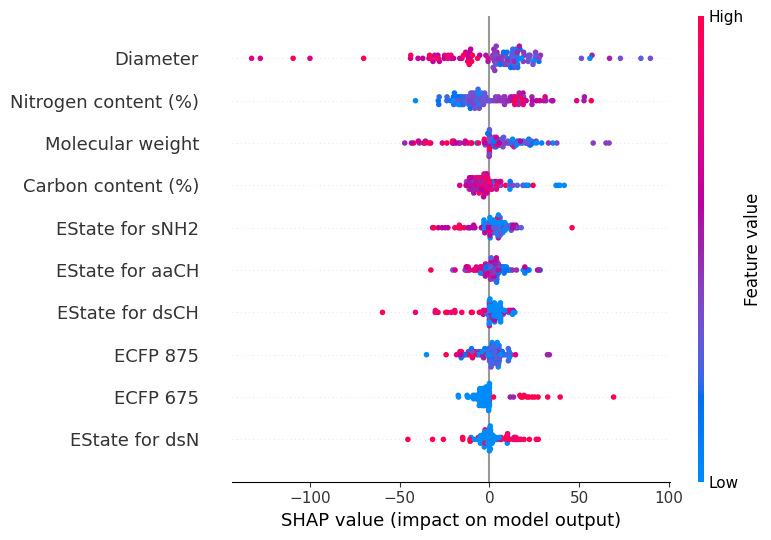

In [6]:
import shap
import matplotlib.pyplot as plt

test_data_all = pd.concat(test_sets, ignore_index=True)
f_imp_all = np.concatenate([f_imp[1] for f_imp in feature_importance_1], axis=0)

test_data_all.rename(columns={
    'diameter': 'Diameter',
    'n%': 'Nitrogen content (%)',
    'mol_wt': 'Molecular weight',
    'c%': 'Carbon content (%)',
    'ecfp_875': 'ECFP 875',
    'ecfp_525': 'ECFP 525',
    'estate_20': 'EState for sNH2',
    'estate_10': 'EState for dsCH',
    'ecfp_675': 'ECFP 675',
    'estate_11': 'EState for aaCH',
    'estate_27': 'EState for dsN',
}, inplace=True)

explanation = shap.Explanation(
    values=f_imp_all,
    data=test_data_all.values,
    feature_names=test_data_all.columns.tolist()
)

shap.plots.beeswarm(explanation, max_display=10, group_remaining_features=False, show=False)
plt.tight_layout()
plt.savefig('feature_importance_best_model.svg', format='svg', dpi=300)

In [7]:
explanation

.values =
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.51837516e+00, -3.19782359e+00,  2.43556221e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.51837516e+00,  2.37171789e+01, -9.16328577e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         4.25955418e+00,  1.43720660e+01, -4.51388403e+00],
       ...,
       [-7.59564510e-02, -5.25950955e-03, -8.72757123e-01, ...,
         1.87317644e-01, -6.30608372e+00, -2.98893953e+00],
       [ 6.19658120e-02, -6.47276548e-03, -6.43938578e-01, ...,
         2.76458593e+00, -1.22221092e+01, -1.90869870e+00],
       [-5.39243164e-01, -6.77992042e-03, -2.55920962e+00, ...,
         3.30906548e+00,  1.04573884e+01,  1.27461897e+01]],
      shape=(115, 419))

.data =
array([[2.        , 2.        , 0.        , ..., 0.        , 0.0952381 ,
        0.9047619 ],
       [0.        , 2.        , 0.        , ..., 0.        , 0.15      ,
        0.85      ],
       [0.  

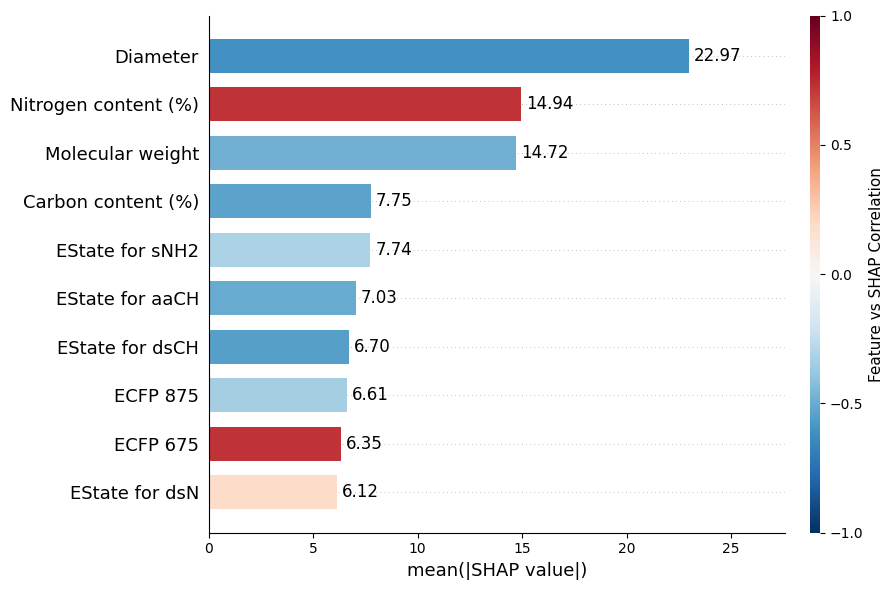

In [8]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from typing import Literal, Sequence

def _get_red_blue_cmap() -> mcolors.LinearSegmentedColormap:
    """Creates a red-blue colormap with a smooth transition from blue to red.

    Returns:
        A colormap object that transitions from blue to red.
    """
    gray_rgb = np.array([0.51615537, 0.51615111, 0.5161729])

    cdict: dict[Literal["red", "green", "blue", "alpha"], Sequence[tuple[float, float, float]]] = {
        "red": [
            (0.0, 0.0, 0.0),
            (0.494949494949495, 0.6035590338007161, 0.6035590338007161),
            (1.0, 1.0, 1.0),
        ],
        "green": [
            (0.0, 0.5433775692459107, 0.5433775692459107),
            (0.494949494949495, 0.14541587318267168, 0.14541587318267168),
            (1.0, 0.0, 0.0),
        ],
        "blue": [
            (0.0, 0.983379062301401, 0.983379062301401),
            (0.494949494949495, 0.6828490076357064, 0.6828490076357064),
            (1.0, 0.31796406298163893, 0.31796406298163893),
        ],
        "alpha": [(0, 1.0, 1.0), (0.494949494949495, 1.0, 1.0), (1.0, 1.0, 1.0)],
    }
    red_blue = mcolors.LinearSegmentedColormap("red_blue", cdict)
    red_blue.set_bad(gray_rgb.tolist(), 1.0)
    red_blue.set_over(gray_rgb.tolist(), 1.0)
    red_blue.set_under(gray_rgb.tolist(), 1.0)
    return red_blue


def shap_correlations(shap_explanation, data_columns, k=10):
    data_values = pd.DataFrame(shap_explanation.data, columns=data_columns)
    shap_values = pd.DataFrame(data=shap_explanation.values, columns=data_columns)
    absolute_means = shap_values.abs().mean(axis=0)
    absolute_means = absolute_means.reset_index(drop=False)
    absolute_means.rename(columns={
        'index': 'feature',
        0: 'value'
    }, inplace=True)
    absolute_means = absolute_means.sort_values(by='value').tail(k)
    correlations = []
    for fname in absolute_means['feature']:
        fvalues = data_values[fname]
        svalues = shap_values[fname]
        corr = fvalues.corr(svalues)
        correlations.append(corr)
    absolute_means['corr'] = correlations

    values = absolute_means['value']
    feature_names = absolute_means['feature']



    # 3. Plotting
    cmap = plt.get_cmap('RdBu_r')
    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)
    bar_colors = [cmap(norm(c)) for c in absolute_means['corr']]

    fig, ax = plt.subplots(figsize=(9, len(values) * 0.6))
    y_pos = np.arange(len(values))

    bars = ax.barh(y_pos, values, color=bar_colors, height=0.7)

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('none')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=13)
    ax.set_xlabel('mean(|SHAP value|)', fontsize=13)

    # Add horizontal dotted lines behind bars
    for i in y_pos:
        ax.axhline(i, color="#888888", lw=0.5, dashes=(1, 5), zorder=-1)

    # 5. Add text labels at the end of bars
    max_val = np.max(values)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + (max_val * 0.01),
            bar.get_y() + bar.get_height()/2,
            f"{val:.2f}",
            va='center',
            ha='left',
            fontsize=12,
            color="black"
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, aspect=50, ticks=[-1, -0.5, 0, 0.5, 1])
    cbar.set_label('Feature vs SHAP Correlation', fontsize=11)
    cbar.outline.set_visible(False)

    # Ensure there is room for the labels
    ax.set_xlim(0, max_val * 1.2)
    return ax
    # plt.tight_layout()
    # plt.show()

ax = shap_correlations(explanation, test_data_all.columns)
plt.tight_layout()
plt.savefig("shap_fi_simple.svg")


In [9]:
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from collections import namedtuple
import re

def make_rect(match):
    cx = match.group(1)
    cy = match.group(2)
    rx = float(match.group(3))
    ry = float(match.group(4))
    atom_class = match.group(5)
    style_str = match.group(6)

    # 2. CALCULATE BOX
    width = rx * 1.5
    height = ry * 1.5
    x = float(cx) - (width / 2)
    y = float(cy) - (height / 2)

    return f"<rect x='{x}' y='{y}' width='{width}' height='{height}' rx='3' class='{atom_class}' style='{style_str}' />"

def hex_replace(match):
    full_style = match.group(0)
    # Find the hex code inside the style string
    hex8 = re.search(r'#([0-9A-Fa-f]{6})([0-9A-Fa-f]{2})', full_style)
    if hex8:
        color, alpha = hex8.groups()
        opacity = round(int(alpha, 16) / 255.0, 3)
        # Replace 8-digit with 6-digit
        fixed = full_style.replace(f"#{color}{alpha}", f"#{color}")
        # Add opacity attributes before the closing quote
        return fixed[:-1] + f";fill-opacity:{opacity};stroke-opacity:{opacity}'"
    return full_style


def replace_circles_with_rectangles(svg):
    pattern = r"<ellipse\s+cx='([^']+)'\s+cy='([^']+)'\s+rx='([^']+)'\s+ry='([^']+)'\s+class='([^']+)'\s+style='([^']+)'\s*/>"

    svg = re.sub(pattern, make_rect, svg)
    return re.sub(r"style='[^']+#([0-9A-Fa-f]{8})[^']*'", hex_replace, svg)


def DrawMorganBits(tpls, **kwargs):
  envs = []
  for tpl in tpls:
    if len(tpl) == 4:
      mol, bitId, bitInfo, whichExample = tpl
    else:
      mol, bitId, bitInfo = tpl
      whichExample = 0

    atomId, radius = bitInfo[bitId][whichExample]
    envs.append((mol, atomId, radius))
  return DrawMorganEnvs(envs, **kwargs)


# adapted from the function drawFPBits._drawFPBit() from the CheTo package
# original author Nadine Schneider
FingerprintEnv = namedtuple(
  'FingerprintEnv',
  ('submol', 'highlightAtoms', 'atomColors', 'highlightBonds', 'bondColors', 'highlightRadii'))


def _getMorganEnv(mol, atomId, radius, baseRad, aromaticColor, ringColor, centerColor, extraColor,
                  **kwargs):
  if not mol.GetNumConformers():
    rdDepictor.Compute2DCoords(mol)
  bitPath = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atomId)

  # get the atoms for highlighting
  atomsToUse = set((atomId, ))
  for b in bitPath:
    atomsToUse.add(mol.GetBondWithIdx(b).GetBeginAtomIdx())
    atomsToUse.add(mol.GetBondWithIdx(b).GetEndAtomIdx())

  #  enlarge the environment by one further bond
  enlargedEnv = set()
  for atom in atomsToUse:
    a = mol.GetAtomWithIdx(atom)
    for b in a.GetBonds():
      bidx = b.GetIdx()
      if bidx not in bitPath:
        enlargedEnv.add(bidx)
  enlargedEnv = list(enlargedEnv)
  enlargedEnv += bitPath

  # set the coordinates of the submol based on the coordinates of the original molecule
  amap = {}
  if enlargedEnv:
    submol = Chem.PathToSubmol(mol, enlargedEnv, atomMap=amap)
  else:
    # generate submol from fragments with no bonds
    submol = Chem.MolFromSmiles(Chem.MolFragmentToSmiles(mol, atomsToUse=atomsToUse))
  Chem.FastFindRings(submol)
  conf = Chem.Conformer(submol.GetNumAtoms())
  confOri = mol.GetConformer(0)
  for i1, i2 in amap.items():
    conf.SetAtomPosition(i2, confOri.GetAtomPosition(i1))
  submol.AddConformer(conf)

  for orig_idx, sub_idx in amap.items():
        sub_atom = submol.GetAtomWithIdx(sub_idx)

        # --- MODIFICATION START ---
        # Check if the atom belongs to the "Core" bit
        if orig_idx in atomsToUse:
            orig_atom = mol.GetAtomWithIdx(orig_idx)
            h_count = orig_atom.GetTotalNumHs()
            degree = orig_atom.GetDegree()
            sub_atom.SetProp("atomNote", f"H:{h_count},D:{degree}")
        else:
            # For atoms outside the core, ensure no label is set
            if sub_atom.HasProp("atomNote"):
                sub_atom.ClearProp("atomNote")
            # Convert to Wildcard as before
            sub_atom.SetAtomicNum(0)
            sub_atom.SetIsAromatic(False)
        # --- MODIFICATION END ---

  envSubmol = []
  for b in bitPath:
      beginAtom = amap[mol.GetBondWithIdx(b).GetBeginAtomIdx()]
      endAtom = amap[mol.GetBondWithIdx(b).GetEndAtomIdx()]
      envSubmol.append(submol.GetBondBetweenAtoms(beginAtom, endAtom).GetIdx())

  # color all atoms of the submol in gray which are not part of the bit
  # highlight atoms which are in rings
  atomcolors, bondcolors = {}, {}
  highlightAtoms, highlightBonds = [], []
  highlightRadii = {}
  for aidx in amap.keys():
    if aidx in atomsToUse:
      color = None
      if centerColor and aidx == atomId:
        color = centerColor
      if color is not None:
        atomcolors[amap[aidx]] = color
        highlightAtoms.append(amap[aidx])
        highlightRadii[amap[aidx]] = baseRad
    else:
      #drawopt.atomLabels[amap[aidx]] = '*'
      submol.GetAtomWithIdx(amap[aidx]).SetAtomicNum(0)
      submol.GetAtomWithIdx(amap[aidx]).UpdatePropertyCache()
  color = extraColor
  for bid in submol.GetBonds():
    bidx = bid.GetIdx()
    if bidx not in envSubmol:
      bondcolors[bidx] = color
      bid.SetBondType(Chem.BondType.OTHER)
      bid.SetIsAromatic(False)

      bondcolors[bidx] = color
      highlightBonds.append(bidx)

  return FingerprintEnv(submol, highlightAtoms, atomcolors, highlightBonds, bondcolors,
                        highlightRadii)


def DrawMorganEnvs(envs, molsPerRow=3, subImgSize=(150, 150), baseRad=0.4, useSVG=True,
                   aromaticColor=(0.9, 0.9, 0.2), ringColor=(0.8, 0.8, 0.8),
                   centerColor=(0.788, 0, 0.329, 0.4), extraColor=(0.9, 0.9, 0.9), legends=None,
                   drawOptions=None, **kwargs):
  submols = []
  highlightAtoms = []
  atomColors = []
  highlightBonds = []
  bondColors = []
  highlightRadii = []
  for mol, atomId, radius in envs:
    menv = _getMorganEnv(mol, atomId, radius, baseRad, aromaticColor, ringColor, centerColor,
                         extraColor, **kwargs)
    submols.append(menv.submol)
    highlightAtoms.append(menv.highlightAtoms)
    atomColors.append(menv.atomColors)
    highlightBonds.append(menv.highlightBonds)
    bondColors.append(menv.bondColors)
    highlightRadii.append(menv.highlightRadii)

  if legends is None:
    legends = [''] * len(envs)

  nRows = len(envs) // molsPerRow
  if len(envs) % molsPerRow:
    nRows += 1

  fullSize = (molsPerRow * subImgSize[0], nRows * subImgSize[1])
  # Drawing
  if useSVG:
    drawer = rdMolDraw2D.MolDraw2DSVG(fullSize[0], fullSize[1], subImgSize[0], subImgSize[1])
  else:
    drawer = rdMolDraw2D.MolDraw2DCairo(fullSize[0], fullSize[1], subImgSize[0], subImgSize[1])

  if drawOptions is None:
    drawOptions = drawer.drawOptions()
  drawOptions.prepareMolsBeforeDrawing = False
  drawOptions.continuousHighlight = False
  drawOptions.includeMetadata = False
  drawer.SetDrawOptions(drawOptions)
  drawer.DrawMolecules(submols, legends=legends, highlightAtoms=highlightAtoms,
                       highlightAtomColors=atomColors, highlightBonds=highlightBonds,
                       highlightBondColors=bondColors, highlightAtomRadii=highlightRadii, **kwargs)
  drawer.FinishDrawing()
  svg = drawer.GetDrawingText()

  return replace_circles_with_rectangles(svg)

In [10]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, SVG

def summarize_bits(smiles_list, target_bit, radius=2, n_bits=2048, use_chiral=True):
    """
    Groups molecules by their core bit structure and visualizes unique cores.
    """
    unique_cores = {}

    for m_idx, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if not mol: continue

        Chem.AssignStereochemistry(mol, force=True, cleanIt=True)
        bit_info = {}
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits, bitInfo=bit_info, useChirality=use_chiral)

        if target_bit in bit_info:
            # Get the core substructure for aggregation
            atomId, rad = bit_info[target_bit][0]
            bitPath = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atomId)

            # Extract just the core (black part) to generate a grouping key
            core_submol = Chem.PathToSubmol(mol, bitPath)
            core_key = Chem.MolToSmiles(core_submol, isomericSmiles=use_chiral)

            if core_key not in unique_cores:
                unique_cores[core_key] = {
                    'mol': mol,
                    'atomId': atomId,
                    'rad': rad,
                    'mol_indices': set()
                }
            unique_cores[core_key]['mol_indices'].add(m_idx)

    # Prepare data for DrawMorganEnvs
    envs_to_draw = []
    legends = []
    for core_key, data in unique_cores.items():
        envs_to_draw.append((data['mol'], data['atomId'], data['rad']))
        legends.append(f"Found in {len(data['mol_indices'])} molecules")

    if not envs_to_draw:
        return "No occurrences found."

    img = DrawMorganEnvs(envs_to_draw, legends=legends, subImgSize=(300, 300))
    return img



def visualize_target_bit(smiles: list, target_bit: int, radius: int = 2, n_bits: int = 2048, use_chiral: bool = True):
    """
    Visualizes a specific Bit ID using RDKit's native DrawMorganBits.
    """
    # 1. Prepare Molecule
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        print("Invalid SMILES")
        return

    # Assign Stereochemistry so RDKit knows about R/S labels
    Chem.AssignStereochemistry(mol, force=True, cleanIt=True)

    # 2. Calculate Fingerprint with Chirality
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=n_bits,
        bitInfo=bit_info,
        useChirality=use_chiral
    )

    # 3. Validation: Check if the user's bit exists
    if target_bit not in bit_info:
        return

    # 4. Prepare Data for DrawMorganBits
    # bit_info[bit_id] is a list of tuples: (atom_index, radius)
    # We want to visualize all instances (e.g. if the bit appears twice)
    instances = bit_info[target_bit]

    tuples_to_draw = []
    legends = []

    print(f"✅ Bit {target_bit} found! Occurrences: {len(instances)}")
    unique_substructures = []
    for i, (atom_idx, rad) in enumerate(instances):
        bitPath = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
        core_submol = Chem.PathToSubmol(mol, bitPath)
        core_key = Chem.MolToSmiles(core_submol, isomericSmiles=use_chiral)

        if core_key in unique_substructures:
            continue  # Skip duplicate substructures
        unique_substructures.append(core_key)
        tuples_to_draw.append((mol, target_bit, bit_info))

        # Create a descriptive legend
        atom_symbol = mol.GetAtomWithIdx(atom_idx).GetSymbol()

        # Check for chirality info on the central atom
        atom_obj = mol.GetAtomWithIdx(atom_idx)
        cip = atom_obj.GetProp('_CIPCode') if atom_obj.HasProp('_CIPCode') else ""
        stereo_str = f"({cip})" if cip else ""

        legends.append(f"Atom: {atom_symbol}{stereo_str} (Idx {atom_idx}) | R: {rad}")

    # 5. Draw
    img = Draw.DrawMorganBits(
        tuples_to_draw,
        molsPerRow=min(len(instances), 4), # Adjust grid size
        subImgSize=(500, 500),
        legends=legends,
        useSVG=True
    )

    return img

def visualize_on_molecule(smiles: str, i, target_bit: int, radius: int = 2, n_bits: int = 2048, use_chiral: bool = True):
    """
    Visualizes a specific Bit ID highlighted on the molecule.
    """
    # 1. Prepare Molecule
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        print("Invalid SMILES")
        return

    # Assign Stereochemistry so RDKit knows about R/S labels
    Chem.AssignStereochemistry(mol, force=True, cleanIt=True)

    # 2. Calculate Fingerprint with Chirality
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=radius, nBits=n_bits, bitInfo=bit_info, useChirality=use_chiral
    )

    if target_bit not in bit_info:
        return None

    instances = bit_info[target_bit]

    # 1. Track highlights and specific colors
    highlight_atoms = []
    highlight_bonds = []
    atom_colors = {}  # Dictionary to map atom index to color (R, G, B)

    # Define our Blue color for the central atoms
    red_color = (0.204, 1, 0.941, 0.4)
    blue_color = (0.788, 0, 0.329, 0.4)

    highlight_atoms = []
    highlight_bonds = []
    atom_colors = {}
    bond_colors = {}

    instances = bit_info[target_bit]

    for atom_idx, rad in instances:
        # Mark center as Blue
        atom_colors[atom_idx] = blue_color
        highlight_atoms.append(atom_idx)

        if rad > 0:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            for b_idx in env:
                # FORCE BONDS TO BE RED
                bond_colors[b_idx] = red_color
                highlight_bonds.append(b_idx)

                # Get atoms connected to this bond
                bond = mol.GetBondWithIdx(b_idx)
                aid1, aid2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()

                # If these atoms aren't the center, make them red
                for aid in [aid1, aid2]:
                    highlight_atoms.append(aid)
                    if aid not in atom_colors: # Don't overwrite the blue center
                        atom_colors[aid] = red_color

    # 3. Draw
    drawer = rdMolDraw2D.MolDraw2DSVG(600, 600)

    # This prevents the "bleeding" of colors
    drawer.drawOptions().prepareMolsBeforeDrawing = True

    drawer.drawOptions().highlightRadius = 0.4
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(set(highlight_atoms)),
        highlightAtomColors=atom_colors,
        highlightBonds=list(set(highlight_bonds)),
        highlightBondColors=bond_colors,
        legend=f'{i}'
    )
    drawer.FinishDrawing()
    img = drawer.GetDrawingText()

    return replace_circles_with_rectangles(img)

In [11]:
RADIUS = 2
N_BITS = 1024
USE_CHIRALITY = True
TARGET_BIT_ID = 875
OUTPUT_FOLDER = "bit_visualizations"

In [12]:
wrong_molecules = [
    'ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)=N5)C=C4)=CC(C6=CC=C(C7=NC(Cl)=NC(Cl)=N7)C=C6)=C3)C=C2)=NC(Cl)=N1',
    'ClC1=NC(Cl)=NC(NC2=CC3=C(C=C2)C(C4=C(C3=O)C=CC(NC5=NC(Cl)=NC(Cl)=N5)=C4)=O)=N1',
    'NC1=CC=C(C2=NC(C3=CC=C(C=C3)N(C(C4=C5C=C(C6=C4)C(N(C(C=C7)=CC=C7C8=NC(C9=CC=C(C=C9)N)=NC(C%10=CC=C(C=C%10)N)=N8)C6=O)=O)=O)C5=O)=NC(C%11=CC=C(C=C%11)N)=N2)C=C1',
    'NC1=CC=C(C2=NC(C3=CC=C(C=C3)N(C(C4=CC=C5C6=C4C7=CC=C6C(N(C8=CC=C(C9=NC(C%10=CC=C(N)C=C%10)=NC(C%11=CC=C(N)C=C%11)=N9)C=C8)C5=O)=O)=O)C7=O)=NC(C%12=CC=C(C=C%12)N)=N2)C=C1',
    'O=C1C(C(c2c(C1=O)nc3cc4nc5cc6nc7c(C(C(C(C7=O)=O)=O)=O)nc6cc5nc4cc3n2)=O)=O',
    'C/C=C1C(/C(C(/C(C\\1=O)=C/Nc2c3cccc(N)c3ccc2)=O)=C\C)=O',
    'CC=c(c(=O)c(=CC)c(=O)c1=CNc2ccc(C(c3cc(N)ccc3C4=O)=O)c4c2)c1=O',
    'O=C(/C(C(/C(C/1=O)=C/Nc2ccc(N)cc2)=O)=C\C)C1=C\C',
    'O=Cc1c(O)c(c(n2)sc3c2cc(sc(c4c(O)c(C=O)c(O)c(C=O)c4O)n5)c5c3)c(O)c(C=O)c1O',
    'O=Cc1cc(c(n2)sc3c2cc(sc(c4cc(C=O)cc(C=O)c4)n5)c5c3)cc(C=O)c1',
    'O=C1C(C(C(C2=C1N=C(C=C3C(N=C(C(C(C(C4=O)=O)=O)=O)C4=N3)=C5)C5=N2)=O)=O)=O',
    'O=C1C(C(c2nc(C(c3nc(C(C(C(C4=O)=O)=O)=O)c4nc3C5=O)=O)c5nc2C1=O)=O)=O',
    'BrC1=CC=C(C(C(C2=CC=C(C=C2)C3=CC=C(C=C3)C4=CC5=C(C=C4Br)SC6=C(C=C(C(Br)=C6)C7=CC=C(C8=CC=C(C(C(C9=CC=C(Br)C=C9)C%10=CC=C(Br)C=C%10)C%11=CC=C(Br)C=C%11)C=C8)C=C7)S5)C%12=CC=C(Br)C=C%12)C%13=CC=C(Br)C=C%13)C=C1',
    'Cc1ccc(C(c2ccccc2)=c(c(cccc3)c3c4=C(c5ccc(C)cc5)c6ccccc6)c7c4cccc7)cc1',
    'Clc1nc(c2ccc(C(c3ccccc3)=c(c(cccc4)c4c5=C(c6ccc(c7nc(Cl)nc(Cl)n7)cc6)c8ccccc8)c9c5cccc9)cc2)nc(Cl)n1',
    'Nc4ccc(N(c1ccc(N)cc1)c3ccc(NC=c2c(O)c(C=O)c(O)c(C=O)c2=O)cc3)cc4',
    'Nc5ccc(c4cc(c1ccc(N)cc1)nc(c3ccc(NC=c2c(O)c(C=O)c(O)c(C=O)c2=O)cc3)c4)cc5',
    'Nc5ccc(n4c1ccc(N)cc1c3cc(NC=c2c(O)c(C=O)c(O)c(C=O)c2=O)ccc34)cc5',
    'CC1=CC2=C(C=C1)N(C3=C2C=C(C)C=C3)C4=CC=C(C=C4)C(C=C5)=CC=C5N6C7=C(C8=C6C=CC(C)=C8)C=C(C)C=C7',
    'CC1=CC2=C(C=C1)N(C3=C2C=C(C)C=C3)C4=CC=C(C=C4)N(C5=CC=C(N6C7=C(C8=C6C=CC(C)=C8)C=C(C)C=C7)C=C5)C(C=C9)=CC=C9N%10C%11=C(C%12=C%10C=CC(C)=C%12)C=C(C)C=C%11',
    'CC1=CC(C2=C3C=CC(C)=C2)=C(C=C1)N3C4=NC(N5C6=C(C7=C5C=CC(C)=C7)C=C(C)C=C6)=NC(N8C9=C(C%10=C8C=CC(C)=C%10)C=C(C)C=C9)=N4',
    'O=C(C1=C2C=CC=C1)N(C3=CC=C(C#N)C=C3)N=C2C4=CC=C(C#N)C=C4',
    'Nc7nc(N)nc(/N=C/c6ccc(B5OB(c2ccc(/C=N/c1nc(N)nc(N)n1)cc2)OB(c4ccc(/C=N/c3nc(N)nc(N)n3)cc4)O5)cc6)n7',
    'Oc(c1)c(O)cc2c1c(cc(O)c(O)c3)c3c4c2cc5c(OB(O5)c6ccc(B7Oc(c8)c(O7)cc9c8c(cc(O)c(O)c%10)c%10c%11c9cc(O)c(O)c%11)cc6)c4',
    'NC1=CC2=C(C=C1)N(CCCCCC)C3=C2C(N(CCCCCC)C4=C5C=C(N)C=C4)=C5C6=C3C7=C(C=CC(N8C(C(C=C(C(N(C(C=C9)=CC%10=C9C%11=C(N%10CCCCCC)C%12=C(N(CCCCCC)C%13=C%12C=C(N)C=C%13)C%14=C%11N(CCCCCC)C%15=C%14C=C(N)C=C%15)C%16=O)=O)C%16=C%17)=C%17C8=O)=O)=C7)N6CCCCCC',
    'CCCCCCN1C(C2=C(C3=C4N(C5=C3C=C(C=C5)N)CCCCCC)N(C6=C2C=C(C=C6)N)CCCCCC)=C4C7=C1C=C(C=C7)/N=C/C8=CC=C(/C=N/C9=CC%10=C(C%11=C(C%12=C(C%13=C%11N(C%14=C%13C=C(C=C%14)N)CCCCCC)N(C%15=C%12C=C(C=C%15)N)CCCCCC)N%10CCCCCC)C=C9)C=C8',
    'O=C(C1=NC2=CC3=C(C=C2N=C1C(C4=O)=O)C5=C(C=C(N=C(C(C(C(C6=O)=O)=O)=O)C6=N7)C7=C5)C8=C3C=C(N=C(C(C(C(C9=O)=O)=O)=O)C9=N%10)C%10=C8)C4=O',
    'O=S(C1=CC=C(OC2=CC=C(/C(C3=CC=C(C)C=C3)=C(C4=CC=C(C)C=C4)/C5=CC=C(C)C=C5)C=C2)C=C1)(C6=CC=C(O)C=C6)=O',
    'NC1=CC=C(C2=C3C=CC(OC4=C5C(C=C6)=C(C7=CC=C(N/C=C8C(/C(C(/C(C\8=O)=C\C)=O)=C/C)=O)C=C7)C=C4)=C9C5=C6OC(C=C2)=C39)C=C1',
    'O=C(C(C=C1)=C2C3=C1C(N(C4=C(N)C(C(N)=C(N)C4=O)=O)C(C3=CC=C25)=O)=O)N(C6=C(N)C(C(N)=C(N)C6=O)=O)C5=O',
    'Nc7ccc(c6cc(c1ccc(N)cc1)cc(c5ccc([n+]4ccc(c3cc[n+](c2ccc(N(=O)=O)cc2N(=O)=O)cc3)cc4)cc5)c6)cc7'
]

def canon_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

wrong_molecules = [canon_smiles(s) for s in wrong_molecules]
wrong_molecules

['Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)c3)cc2)n1',
 'O=C1c2ccc(Nc3nc(Cl)nc(Cl)n3)cc2C(=O)c2ccc(Nc3nc(Cl)nc(Cl)n3)cc21',
 'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(-n4c(=O)c5cc6c(=O)n(-c7ccc(-c8nc(-c9ccc(N)cc9)nc(-c9ccc(N)cc9)n8)cc7)c(=O)c6cc5c4=O)cc3)n2)cc1',
 'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(N4C(=O)c5ccc6c7c(ccc(c57)C4=O)C(=O)N(c4ccc(-c5nc(-c7ccc(N)cc7)nc(-c7ccc(N)cc7)n5)cc4)C6=O)cc3)n2)cc1',
 'O=c1c(=O)c(=O)c2nc3cc4nc5cc6nc7c(=O)c(=O)c(=O)c(=O)c7nc6cc5nc4cc3nc2c1=O',
 'C/C=C1/C(=O)C(=CNc2cccc3c(N)cccc23)C(=O)/C(=C/C)C1=O',
 'CC=C1C(=O)C(=CC)C(=O)C(=CNc2ccc3c(c2)C(=O)c2ccc(N)cc2C3=O)C1=O',
 'C/C=C1\\C(=O)/C(=C\\Nc2ccc(N)cc2)C(=O)/C(=C/C)C1=O',
 'O=Cc1c(O)c(C=O)c(O)c(-c2nc3cc4sc(-c5c(O)c(C=O)c(O)c(C=O)c5O)nc4cc3s2)c1O',
 'O=Cc1cc(C=O)cc(-c2nc3cc4sc(-c5cc(C=O)cc(C=O)c5)nc4cc3s2)c1',
 'O=c1c(=O)c(=O)c2nc3cc4nc5c(=O)c(=O)c(=O)c(=O)c5nc4cc3nc2c1=O',
 'O=C1c2nc3c(=O)c(=O)c(=O)c(=O)c3nc2C(=O)c2nc3c(=O)c(=O)c(=O)c(=O)c3nc21',
 'Brc1ccc(C(c2ccc(

[19:41:36] DEPRECATION WARNING: please use MorganGenerator


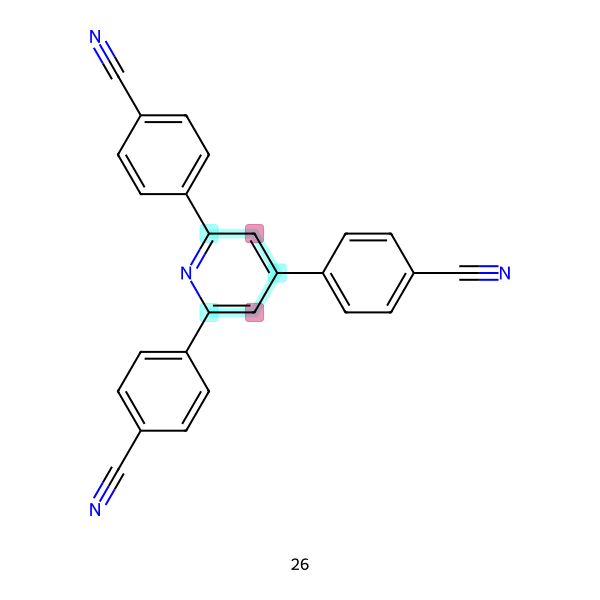

[19:41:36] DEPRECATION WARNING: please use MorganGenerator


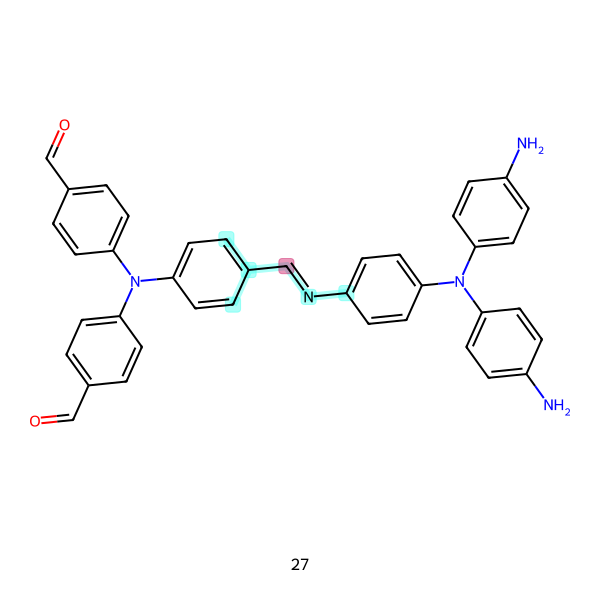

[19:41:36] DEPRECATION WARNING: please use MorganGenerator


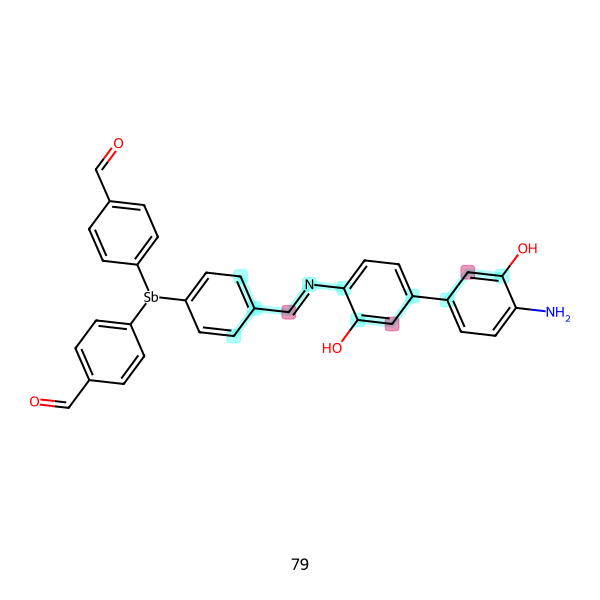

In [13]:
for i in [26, 27, 79]: #range(len(smiles_lists)):
    s = smiles_lists[i]
    if canon_smiles(s) in wrong_molecules:
        continue
    img = visualize_on_molecule(s, i, TARGET_BIT_ID, radius=RADIUS, n_bits=N_BITS,
                         use_chiral=USE_CHIRALITY)

    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_FOLDER, f"ECFP{TARGET_BIT_ID}"), exist_ok=True)

    # with open(f'{OUTPUT_FOLDER}/ECFP{TARGET_BIT_ID}/example_{i}.svg', 'w') as f:
    #      f.write(img)

    display(SVG(img))

[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerator
[19:41:36] DEPRECATION WARNING: please use MorganGenerat

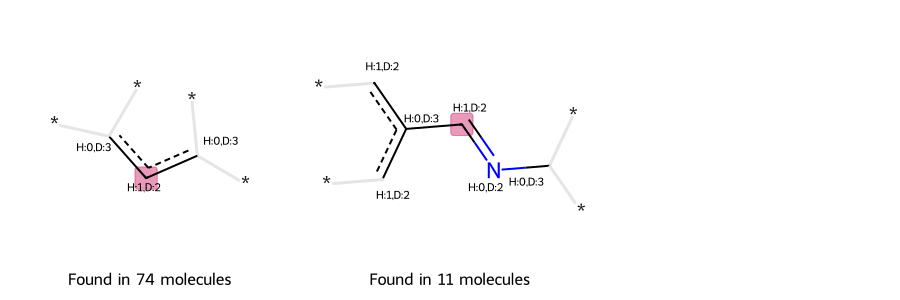

In [14]:
import warnings
warnings.simplefilter("ignore") # pearl aqua

#smiles_lists should be your list of SMILES strings
# for s in smiles_lists:
#     img = visualize_target_bit(s, TARGET_BIT_ID, radius=RADIUS, n_bits=N_BITS,
#                          use_chiral=USE_CHIRALITY)
#     display(img)
img = summarize_bits(smiles_lists, TARGET_BIT_ID, radius=RADIUS, n_bits=N_BITS,
               use_chiral=USE_CHIRALITY)
with open(f'{OUTPUT_FOLDER}/ECFP{TARGET_BIT_ID}/all_types.svg', 'w') as f:
        f.write(img)
    # print(f"Saved: {filename}")
display(SVG(img))

In [15]:
print(img)

<?xml version='1.0' encoding='iso-8859-1'?>
<svg version='1.1' baseProfile='full'
              xmlns='http://www.w3.org/2000/svg'
                      xmlns:rdkit='http://www.rdkit.org/xml'
                      xmlns:xlink='http://www.w3.org/1999/xlink'
                  xml:space='preserve'
width='900px' height='300px' viewBox='0 0 900 300'>
<!-- END OF HEADER -->
<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='300.0' height='300.0' x='0.0' y='0.0'> </rect>
<rect x='134.92499999999998' y='166.92499999999998' width='22.35' height='22.35' rx='3' class='atom-3' style='fill:#C80053;fill-rule:evenodd;stroke:#C80053;stroke-width:1.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1;fill-opacity:0.4;stroke-opacity:0.4' />
<path class='bond-0 atom-0 atom-1' d='M 192.0,101.2 L 197.3,155.7' style='fill:none;fill-rule:evenodd;stroke:#E5E5E5;stroke-width:3.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1' />
<path class='bond-1 atom-1 atom-2' d='M 197.3,155.7

[ND1H2]-*


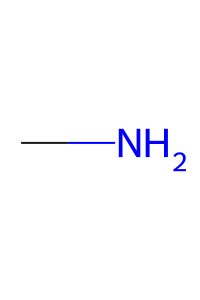

[C,c;D2H](:*):*


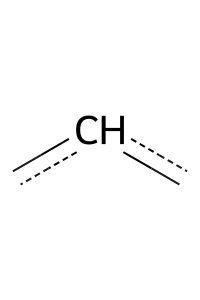

[CD2H](=*)-*


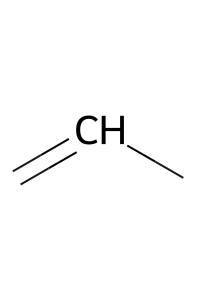

[ND2H0](=*)-*


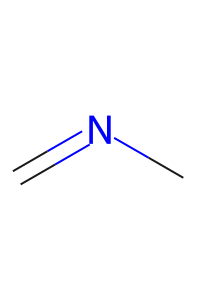

[ND1H2]-*


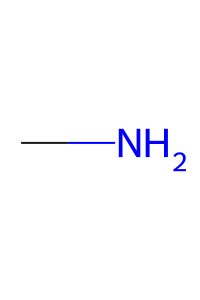

In [16]:
from rdkit.Chem.EState.AtomTypes import _rawD

patterns = {
    20: "[NH2]-*",

    # 11: aaCH (Aromatic Carbon with one Hydrogen)
    # The ':' indicates aromatic bonds
    11: "[cH](:*):*",

    # 10: sCH (Alkene Carbon with one Hydrogen)
    # The '=' indicates the double bond
    10: "[CH](=*)-*",

    # 27: sN (Nitrogen with a double bond, e.g., Imine or Pyridine)
    27: "[N](=*)-*",
}

def visualize_estate_substructure(id):
    feature_names = [name for name, smarts in _rawD]
    dict = {i: smarts for i, (name, smarts) in enumerate(_rawD)}
    print(dict[id])
    smarts = patterns[id]
    mol = Chem.MolFromSmarts(smarts)

    mol.UpdatePropertyCache(strict=False)

    # 2. MANUALLY SET LABELS (The Secret Sauce)
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        num_h = atom.GetNumExplicitHs() # This reads the '2' in [NH2]

        if symbol == "*":
            # Make dummy atoms invisible so we focus on the group
            atom.SetProp("atomLabel", " ")
        else:
            # Build the label: Symbol + H + count
            label = symbol
            if num_h > 0:
                h_text = "H" + (f"<sub>{num_h}</sub>" if num_h > 1 else "")
                label += h_text
            atom.SetProp("atomLabel", label)

    drawer = rdMolDraw2D.MolDraw2DSVG(200, 300)
    options = drawer.drawOptions()
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    svg_text = drawer.GetDrawingText()
    return svg_text


for i in [20, 11, 10, 27]:
    img = visualize_estate_substructure(i)
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_FOLDER, f"EState{i}"), exist_ok=True)
    with open(f'{OUTPUT_FOLDER}/EState{i}/sub.svg', 'w') as f:
        f.write(img)
    display(SVG(img))
img = visualize_estate_substructure(20)
display(SVG(img))

21 Nc1cccc2c(/N=C/c3cc(C=O)c(O)c(C=O)c3O)cccc12


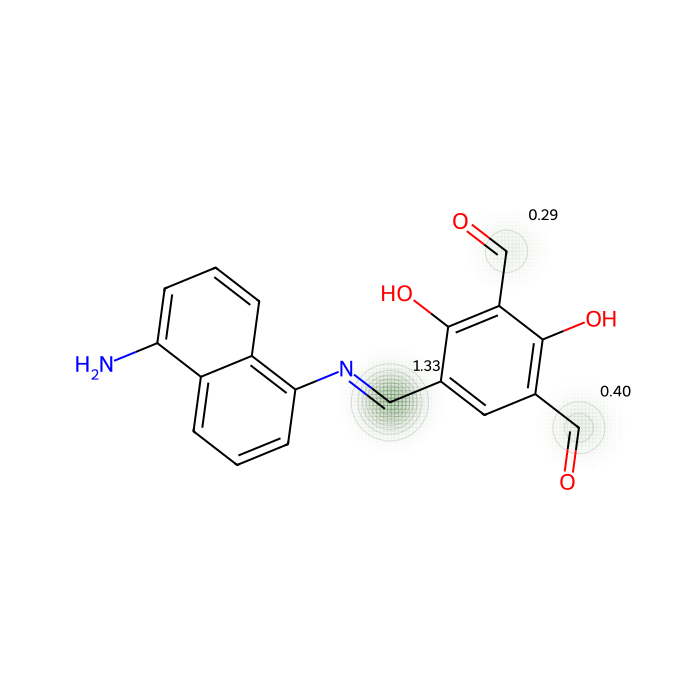

27 Nc1ccc(N(c2ccc(N)cc2)c2ccc(/N=C/c3ccc(N(c4ccc(C=O)cc4)c4ccc(C=O)cc4)cc3)cc2)cc1


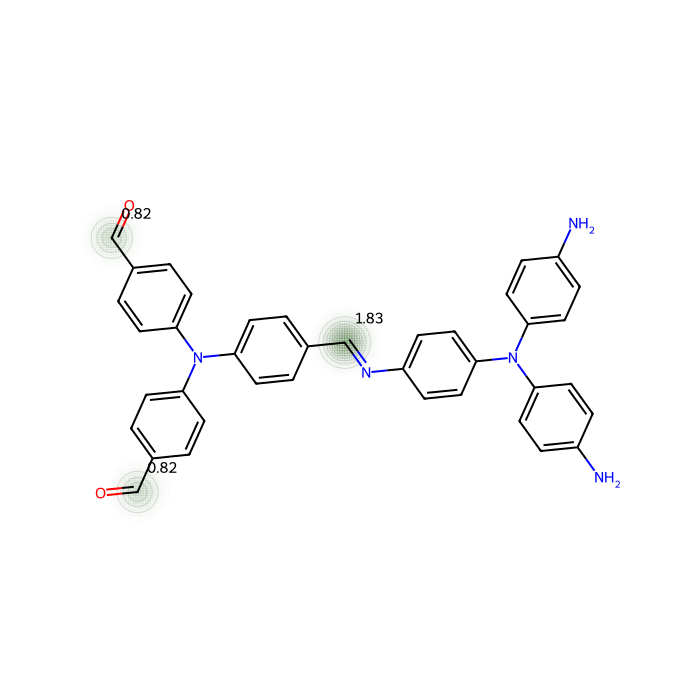

73 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(N=Cc4cc(C=O)cc(C=O)c4O)nc3)n2)cn1


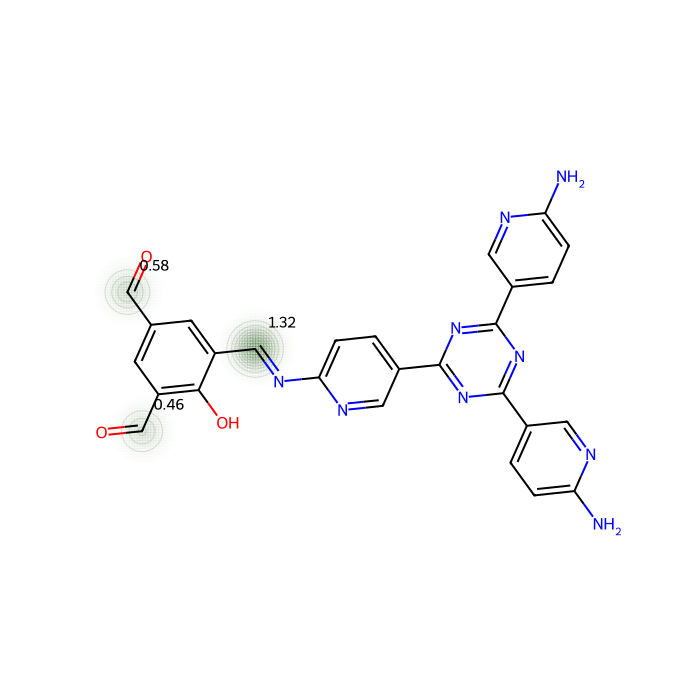

In [17]:
from rdkit.Geometry import Point2D
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import EState
from rdkit.Chem.Draw import SimilarityMaps
import io
import cairosvg
from IPython.display import Image
def estate_types():
    from rdkit.Chem.EState.AtomTypes import _rawD

    feature_names = [name for name, smarts in _rawD]
    return np.asarray(feature_names, dtype=object)
ESTATE_TYPES = estate_types()

def visualize_estate_heatmap(smiles: str, idd, feature_id: int, all_smiles: list = None):

    mol = Chem.MolFromSmiles(smiles)

    if not mol: return None
    AllChem.Compute2DCoords(mol)
    conformer = mol.GetConformer()

    # 1. Calculate Full EState Indices (Intrinsic + Delta) for all atoms
    estate_indices = EState.EStateIndices(mol)

    target_type_name = ESTATE_TYPES[feature_id]

    max_weight = 0
    for s in all_smiles:
        estate = EState.EStateIndices(Chem.MolFromSmiles(s))
        atom_types = EState.AtomTypes.TypeAtoms(Chem.MolFromSmiles(s))
        atom_types = [t[0] if len(t) > 0 else '' for t in atom_types ]
        for i, a_type in enumerate(atom_types):
            if a_type == target_type_name:
                if abs(estate[i]) > max_weight:
                    max_weight = abs(estate[i])

    # 2. Get the Kier-Hall type string for every atom in the molecule
    # This returns a list of strings like ('sCH3', 'ssCH2', etc.)
    atom_types = EState.AtomTypes.TypeAtoms(mol)
    atom_types = [t[0] if len(t) > 0 else '' for t in atom_types ]  # Extract just the type names

    # 3. Identify the target type name from the feature_id
    if not (0 <= feature_id < len(ESTATE_TYPES)):
        print(f"Invalid ID: {feature_id}. Use 0-78.")
        return None


    # 4. Filter weights: only atoms matching the requested EState type get a value
    weights = []
    matching_atoms = [] # To store which atoms we want to label
    for i, a_type in enumerate(atom_types):
        if a_type == target_type_name:
            weights.append(float(estate_indices[i]))
            matching_atoms.append(i)
        else:
            weights.append(0.0)

    sum_weights = round(sum(weights), 2)
    if not matching_atoms:
        return None

    drawer = rdMolDraw2D.MolDraw2DSVG(700, 700)

    if max_weight > 0:
        h_weights = [w / max_weight for w in weights]
    else:
        h_weights = weights

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        h_weights,
        draw2d=drawer,
        step=0.01,
        sigma=0.5,
    )

    for idx in matching_atoms:
        # Get atom position in Angstroms
        pos = conformer.GetAtomPosition(idx)
        atom_pos = Point2D(pos.x + 1, pos.y + 1)
        # Get the raw EState value
        val_text = f"{estate_indices[idx]:.2f}"
        # Draw the value slightly offset from the atom center
        # We use rawCoords=True because atom positions are in Angstroms
        drawer.SetFontSize(15)
        drawer.DrawString(val_text, atom_pos, rawCoords=False)

    # text_pos = Point2D(50, 50)
    # drawer.SetFontSize(12)
    #
    # drawer.DrawString(
    #     f"{idd}, sum: {sum_weights}",
    #     text_pos,
    #     rawCoords=True
    # )

    drawer.FinishDrawing()
    svg_text = drawer.GetDrawingText()

    return svg_text

# --- Usage Example ---
feature = 10
j = 0
for i in [21, 27, 73]:#range(len(smiles_lists)):
    s = smiles_lists[i]
    if canon_smiles(s) in wrong_molecules:
        print(s, 'wrong')
        continue
    print(i, s)
    img = visualize_estate_heatmap(s, i, feature, smiles_lists)
    if img is not None:
        # with open(f'{OUTPUT_FOLDER}/EState{feature}/example_{i}.svg', 'w') as f:
        #     img = re.sub(r"style='[^']+#([0-9A-Fa-f]{8})[^']*'", hex_replace, img)
        #     f.write(img)
        display(SVG(img))
        j += 1
    if j >= 30:  # Limit to first 5 for demonstration
        break
# smiles = "CC1=CC=C(C)C=C1" # Para-xylene
# feature = 10 # aaCH (Aromatic carbons)
# img = visualize_estate_heatmap(smiles, feature)
# if img: display(img)

In [18]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, rdmolops, GetDistanceMatrix
from IPython.display import display # Required to show images in a loop in Notebooks

# 1. Helper function to calculate diameter and get path indices
def get_diameter_path(mol: Chem.Mol):
    # Calculate Distance Matrix
    dm = GetDistanceMatrix(mol)

    # Get diameter value
    diameter_val = int(np.max(dm))

    # Find start and end atoms (indices of the max value in the matrix)
    flat_idx = np.argmax(dm)
    source_idx, target_idx = np.unravel_index(flat_idx, dm.shape)

    # Get the path atoms
    path_atoms = list(rdmolops.GetShortestPath(mol, int(source_idx), int(target_idx)))

    # Get the path bonds (for nice continuous lines)
    path_bonds = []
    for i in range(len(path_atoms) - 1):
        bond = mol.GetBondBetweenAtoms(path_atoms[i], path_atoms[i+1])
        if bond:
            path_bonds.append(bond.GetIdx())

    return diameter_val, path_atoms, path_bonds

def save_diameter_svg(mol, filename, width=300, height=300):
    d_val, atoms, bonds = get_diameter_path(mol)

    # Initialize the SVG drawer
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)

    opts = drawer.drawOptions()
    opts.addStereoAnnotation = False

    # Draw the molecule
    drawer.DrawMolecule(
        mol,
        highlightAtoms=atoms,
        highlightBonds=bonds,
        legend=f"Diameter: {d_val}"
    )

    # Finalize and get the SVG string
    drawer.FinishDrawing()
    svg_string = drawer.GetDrawingText()
    return svg_string

    # Write to file
    # with open(filename, 'w') as f:
    #     f.write(svg_string)
    # print(f"Saved: {filename}")

dataset = [Chem.MolFromSmiles(s) for s in smiles_lists]

ids = [0, 2, 4, 8, 9, 31]
smiles_ids = [smiles_lists[i] for i in ids]

names = [smiles_lists[1], smiles_lists[15]]
imgs = []

for i, mol in enumerate(smiles_ids):
    m = Chem.MolFromSmiles(mol)
    print(i, mol, get_diameter_path(m)[0])
    img = save_diameter_svg(m, f'diameter_{i}.svg', width=300, height=300)
    imgs.append(img)


0 CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(C#N)cc2)n3-c2ccc(C(C)C)cc2)cc1 16
1 N#Cc1cncc(C#N)c1 6
2 Nc1ccc(N(c2ccc(N)cc2)c2ccc(NC=C3C(=O)C(C=O)=C(O)C(C=O)=C3O)cc2)cc1 16
3 Cc1ccc2c(c1)c1cc(C)ccc1n2-c1nc(-n2c3ccc(C)cc3c3cc(C)ccc32)nc(-n2c3ccc(C)cc3c3cc(C)ccc32)n1 14
4 CCCCCCn1c2ccc(N)cc2c2c1c1c3cc(N)ccc3n(CCCCCC)c1c1c3cc(-n4c(=O)c5cc6c(=O)n(-c7ccc8c9c%10c(c%11cc(N)ccc%11n%10CCCCCC)c%10c(c%11cc(N)ccc%11n%10CCCCCC)c9n(CCCCCC)c8c7)c(=O)c6cc5c4=O)ccc3n(CCCCCC)c21 34
5 CCCCCCn1c2ccc(N)cc2c2c1c1c3ccc(/N=C/c4ccc(/C=N/c5ccc6c7c8c(c9cc(N)ccc9n8CCCCCC)c8c(c9cc(N)ccc9n8CCCCCC)c7n(CCCCCC)c6c5)cc4)cc3n(CCCCCC)c1c1c3cc(N)ccc3n(CCCCCC)c21 35


In [19]:
import math
import cairosvg
import io
from PIL import Image

def save_svg_list_as_png_grid(svg_list, output_filename, mols_per_row=3, dpi=300):
    if not svg_list:
        return

    # 1. Determine cell size from the first SVG
    w_match = re.search(r'width=[\'"](\d+)px[\'"]', svg_list[0])
    h_match = re.search(r'height=[\'"](\d+)px[\'"]', svg_list[0])
    cell_w = int(w_match.group(1)) if w_match else 300
    cell_h = int(h_match.group(1)) if h_match else 300

    # 2. Build the Master SVG string
    rows = math.ceil(len(svg_list) / mols_per_row)
    total_w = cell_w * mols_per_row
    total_h = cell_h * rows

    combined_svg = [
        f'<svg version="1.1" xmlns="http://www.w3.org/2000/svg" '
        f'width="{total_w}" height="{total_h}">'
    ]

    for i, svg_str in enumerate(svg_list):
        x = (i % mols_per_row) * cell_w
        y = (i // mols_per_row) * cell_h

        # Clean the string (remove XML headers)
        clean_svg = re.sub(r'<\?xml.*?\?>|<!DOCTYPE.*?>', '', svg_str)
        # Nest inside a new svg tag with coordinates
        combined_svg.append(f'<svg x="{x}" y="{y}">{clean_svg}</svg>')

    combined_svg.append('</svg>')
    full_svg_string = "".join(combined_svg)

    # 3. Convert the Master SVG to PNG
    # We use scale to increase the DPI/Quality if needed
    cairosvg.svg2png(bytestring=full_svg_string.encode('utf-8'),
                     write_to=output_filename,
                     scale=2.0) # scale=2.0 makes it sharper/double resolution

    print(f"Grid saved as PNG: {output_filename}")

# --- EXECUTION ---
output_png = "diameter_grid.png"
save_svg_list_as_png_grid(imgs, output_png, mols_per_row=3, dpi=300)

Grid saved as PNG: diameter_grid.png
